# 🧰 Classic alternatives: diversified multi-strategy basket

## 🧭 tl;dr

This notebook combines transparent proxies for event-driven, volatility, convertible, defensive equity, macro, and trend sleeves to study the diversification logic behind a multi-strategy alternatives portfolio.

> Educational research only. This notebook is not financial advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Read from top to bottom: understand the economic idea, inspect the exact rule, then compare the formal test results with the robustness checks. Finish with <strong>What went well / what went wrong</strong> to see why a backtest is evidence—not proof.
</div>

## 🧭 Context & methods

Multi-strategy hedge funds allocate across return streams that respond differently to markets. AQR’s public DELTA case describes a systematic portfolio spanning managed futures, global macro, long/short equity, equity market neutral, event driven, convertible arbitrage, and fixed-income relative value. This notebook builds a deliberately simple liquid proxy basket; it is not a fund replication.

### 🔧 Key assumptions

- Proxy sleeves: MNA, PBP, CWB, USMV, TLT, GLD, and a diversified trend sleeve built from SPY/TLT/GLD/DBC/EFA/EEM.
- Monthly inverse-volatility weights are used as a transparent risk-balancing rule.
- SPY is the benchmark; all ETF fees and internal strategy turnover are not fully decomposed.
- The notebook compares equal-weight and inverse-volatility controls.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    dual_momentum_weights,
    inverse_volatility_weights,
    minimum_variance_weights,
    run_portfolio_backtest,
)
from src.research import metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data

The notebook uses adjusted daily closes when available. Missing assets are removed through a common-date intersection; if the download fails, deterministic demo data keeps the code path testable without pretending the synthetic results are market evidence.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['MNA', 'PBP', 'CWB', 'USMV', 'TLT', 'GLD', 'DBC', 'SPY', 'EFA', 'EEM']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=121, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=122, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=123, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=124, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=125, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=126, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=127, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=128, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=129, start='2006-01-01')['close'].rename(t)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2013-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=121, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=122, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=123, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=124, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=125, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=126, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=127, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=128, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=129, start='2006-01-01')['close'].rename(t)], axis=1)

close = close.dropna(how='any')
splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print('Assets:', ', '.join(close.columns))


Data: 2013-01-02 through 2025-12-31 (3,270 common trading days)
Assets: CWB, DBC, EEM, EFA, GLD, MNA, PBP, SPY, TLT, USMV


## 📜 Strategy rules

- Treat each liquid ETF as a rough alternative-strategy sleeve.
- Use monthly inverse-volatility weights across the proxy sleeves.
- Compare with an equal-weight basket and SPY.
- Use the conclusion to separate diversification benefits from actual manager skill.

This construction is intentionally modest: it does not add leverage, optimize correlations, or estimate strategy-level returns from hedge-fund databases.

In [3]:
trend_assets = ['SPY', 'TLT', 'GLD', 'DBC', 'EFA', 'EEM']
trend_sleeves = []
for lookback in [21, 63, 126, 252]:
    trailing = close[trend_assets].pct_change(lookback).shift(1)
    sleeve = pd.DataFrame(0.0, index=close.index, columns=trend_assets)
    month_start = pd.Series(close.index.to_period('M'), index=close.index).ne(pd.Series(close.index.to_period('M'), index=close.index).shift(1)).to_numpy()
    for timestamp in close.index[month_start]:
        valid = trailing.loc[timestamp].dropna()
        if not valid.empty:
            sleeve.loc[timestamp, valid.index] = np.sign(valid) / len(valid)
    trend_sleeves.append(sleeve.ffill().fillna(0.0))
trend_weights = sum(trend_sleeves) / len(trend_sleeves)
trend_returns = (trend_weights.shift(1).fillna(0.0) * close[trend_assets].pct_change().fillna(0.0)).sum(axis=1)
trend_index = (1.0 + trend_returns).cumprod().rename('TREND') * 100.0

proxy_assets = ['MNA', 'PBP', 'CWB', 'USMV', 'TLT', 'GLD', 'DBC']
portfolio_close = pd.concat([close[proxy_assets], trend_index], axis=1).dropna()
weights = inverse_volatility_weights(portfolio_close, lookback=60)


## 📈 Formal test results

The untouched final 20% of the chronological sample is used for the headline table. Parameters are defined before reading the final test outputs.

In [4]:
result = run_portfolio_backtest(portfolio_close, weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns)
test_metrics = metrics_for_period(result, splits['test'].index)
test_table = pd.DataFrame([test_metrics], index=['Classic alternatives multi-strategy basket'])
format_map = {
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
}
display(test_table.style.format(format_map))
print('Formal test findings:')
print(f"  Sharpe={test_metrics['sharpe_ratio']:.2f} | annualized return={test_metrics['annualized_return']:.2%} | max drawdown={test_metrics['max_drawdown']:.2%}")


,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Classic alternatives multi-strategy basket,3.93%,2.90%,1.34,1.94,-2.65%,1.48,56.88%,2.41,31,10.52%,0.706637,-60.15%


Formal test findings:
  Sharpe=1.34 | annualized return=3.93% | max drawdown=-2.65%


## 📊 Equity curve and drawdown

The chart normalizes the strategy and SPY benchmark to one at the start of the formal test period. Drawdown is shown below it so a smooth return path is not mistaken for low risk.

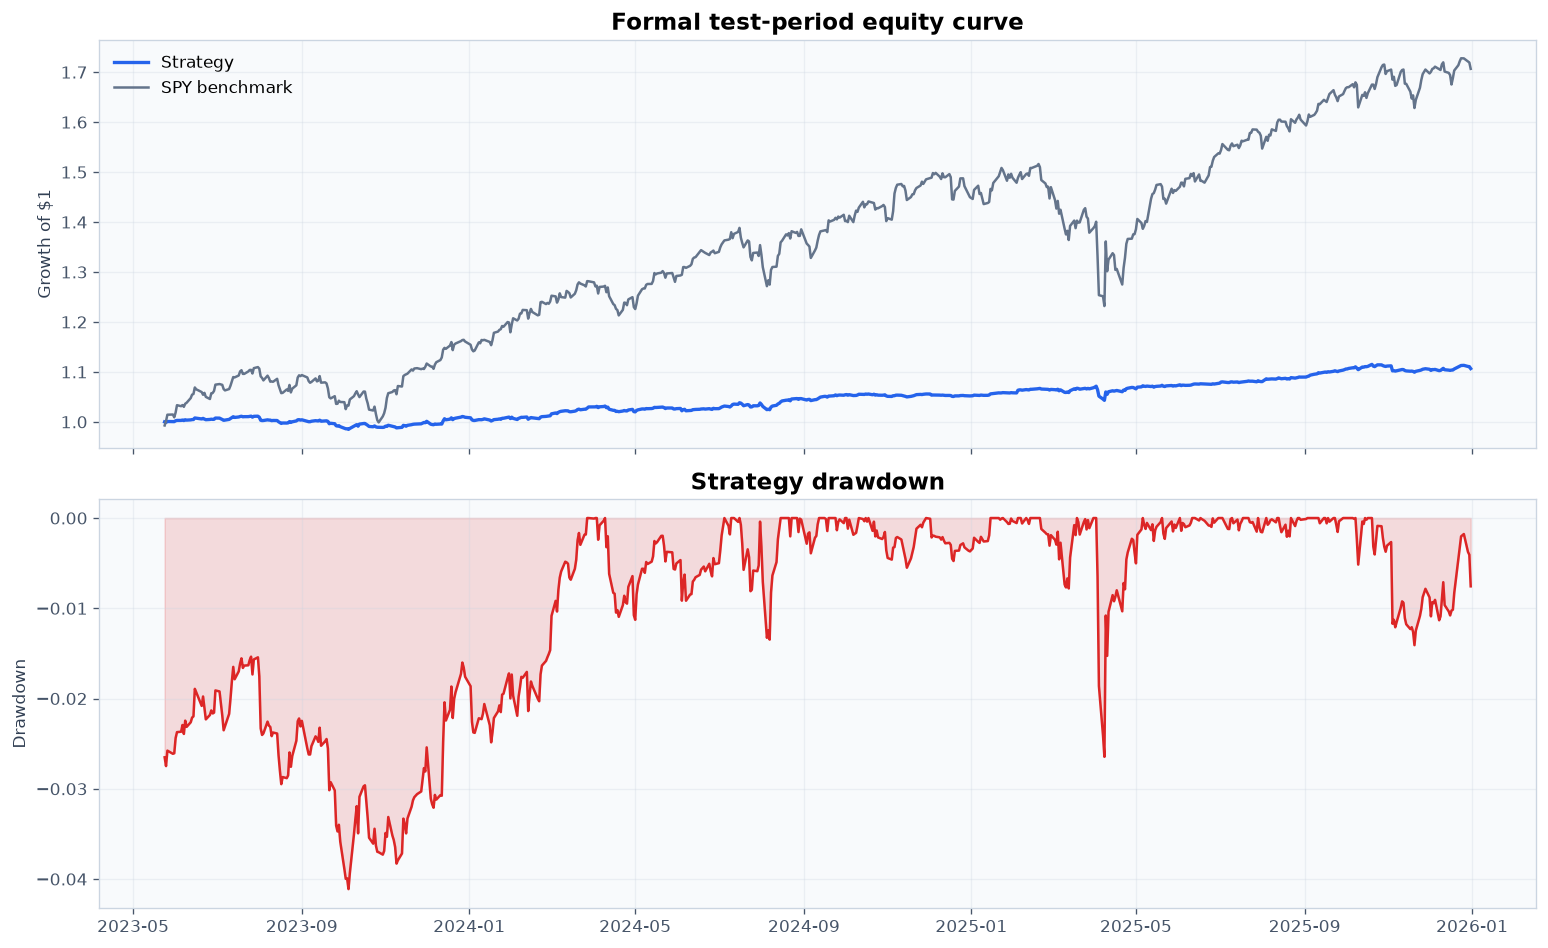

In [5]:
test_index = splits['test'].index
equity = result.frame.loc[test_index, 'equity']
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(equity.index, equity / equity.iloc[0], color='#2563EB', linewidth=2, label='Strategy')
benchmark_curve = (1.0 + result.frame.loc[test_index, 'benchmark_returns']).cumprod()
axes[0].plot(benchmark_curve.index, benchmark_curve, color='#64748B', linewidth=1.5, label='SPY benchmark')
axes[0].set_title('Formal test-period equity curve')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(alpha=0.3)
drawdown = result.frame.loc[test_index, 'drawdown']
axes[1].plot(drawdown.index, drawdown, color='#DC2626', linewidth=1.5)
axes[1].fill_between(drawdown.index, drawdown, 0, color='#DC2626', alpha=0.15)
axes[1].set_title('Strategy drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.3)
plt.show()


## 🛡️ Robustness and crisis diagnostics

These checks are descriptive. Cost sensitivity shows how much implementation friction matters; crisis windows show failure modes and are not additional untouched test sets.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    candidate = run_candidate(cost_bps) if 'run_candidate' in locals() else None
    if candidate is None:
        if 'weights' in locals():
            candidate = run_portfolio_backtest(close, weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
        else:
            candidate = run_backtest(close.iloc[:, 0], target, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
    metrics = metrics_for_period(candidate, splits['test'].index)
    cost_rows.append({'cost_bps': cost_bps, 'test_return': metrics['annualized_return'], 'test_sharpe': metrics['sharpe_ratio'], 'max_drawdown': metrics['max_drawdown'], 'turnover': metrics['annualized_turnover']})
cost_table = pd.DataFrame(cost_rows).set_index('cost_bps')
display(cost_table.style.format({'test_return': '{:.2%}', 'test_sharpe': '{:.2f}', 'max_drawdown': '{:.2%}', 'turnover': '{:.2f}'}))

stress_windows = {
    'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
    'COVID shock': ('2020-02-19', '2020-03-23'),
    '2022 inflation/rates shock': ('2022-01-03', '2022-10-14'),
}
stress_rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    if len(index) == 0:
        continue
    returns = result.frame.loc[index, 'net_returns']
    path = (1.0 + returns).cumprod()
    stress_rows.append({'window': window, 'return': path.iloc[-1] - 1.0, 'max_drawdown': (path / path.cummax() - 1.0).min()})
stress_table = pd.DataFrame(stress_rows).set_index('window')
display(stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'}))


,test_return,test_sharpe,max_drawdown,turnover
cost_bps,,,,
0,4.60%,1.66,-2.65%,1.30
5,4.53%,1.64,-2.65%,1.30
10,4.47%,1.61,-2.65%,1.30
25,4.26%,1.54,-2.65%,1.30
50,3.93%,1.41,-2.65%,1.30


,return,max_drawdown
window,,
COVID shock,-4.53%,-5.05%
2022 inflation/rates shock,-4.27%,-5.47%


## ⚖️ What went well / what went wrong

**What went well:** The basket makes multi-strategy diversification tangible and shows how risk balancing can change the portfolio even when the underlying sleeves are simple ETFs.

**What went wrong:** The proxies are not independent hedge-fund returns, and inverse volatility is not the same as a manager’s risk budget. The basket inherits ETF fees, liquidity, factor overlap, and hidden equity beta.

**Research judgment:** A diversified basket can reduce drawdown while also reducing upside. Report the result as an allocation experiment, not evidence that a hedge fund’s proprietary process has been reproduced.

> The displayed metrics are sample-specific proxy results. They should be interpreted alongside costs, turnover, stress windows, and implementation gaps.